
# Milestone-03: Geographical Analysis

# Visualizing U.S. Natural Disaster Declarations

# Aim

->The purpose of this milestone is to study and visualize how natural disaster declarations are distributed across different parts of the United States.
->This analysis aims to identify regions with higher disaster occurrences and understand variations across states and geographical areas.
->The study transforms summarized disaster data into visual representations to highlight patterns that are not easily visible in raw data.

In [47]:
# Import libraries used for data manipulation and visualization

import pandas as pd          # For reading and processing data
import numpy as np           # For numerical operations
import matplotlib.pyplot as plt   # For creating plots
import seaborn as sns        # For statistical visualizations
import plotly.express as px  # For interactive maps and charts
import geopandas as gpd      # For geospatial data handling

In [48]:
# Load the cleaned dataset created in Milestone-1

df = pd.read_csv(r"C:\Users\RISHI\Desktop\USND\notebooks\datasets.csv")

# Display first few rows to understand the dataset
print(df.head())


  declarationNumber declarationType declarationDate state county incidentType  \
0              DR-1        Disaster      1953-05-02    GA    NaN      Tornado   
1              DR-2        Disaster      1953-05-15    TX    NaN      Tornado   
2              DR-3        Disaster      1953-05-29    LA    NaN        Flood   
3              DR-4        Disaster      1953-06-02    MI    NaN      Tornado   
4              DR-5        Disaster      1953-06-06    MT    NaN        Flood   

                incidentTitle   startDate     endDate   closeDate  \
0                     Tornado  05/02/1953  05/02/1953  06/01/1954   
1  Tornado and Heavy Rainfall  05/15/1953  05/15/1953  01/01/1958   
2                       Flood  05/29/1953  05/29/1953  02/01/1960   
3                     Tornado  06/02/1953  06/02/1953  02/01/1956   
4                      Floods  06/06/1953  06/06/1953  12/01/1955   

  individualAssistanceProgram individualsAndHouseholdsProgram  \
0                         Yes    

## Dataset Validation

Before proceeding with the analysis, the dataset is validated to ensure consistency and completeness. Missing values in the state column are checked and removed to maintain data accuracy.

In [49]:
# Check missing values in important columns
print("Missing values per column:")
print(df.isnull().sum())

# Remove rows with missing state values
df = df.dropna(subset=['state'])

# Check number of unique states
print("Number of States:", df['state'].nunique())

Missing values per column:
declarationNumber                      0
declarationType                        0
declarationDate                        0
state                                  0
county                               197
incidentType                           0
incidentTitle                          0
startDate                              0
endDate                              342
closeDate                          10975
individualAssistanceProgram            0
individualsAndHouseholdsProgram        0
publicAssistanceProgram                0
hazardMitigationProgram                0
year                                   0
month                                  0
dtype: int64
Number of States: 59


## Interpretation

The dataset contains valid records across multiple states, making it suitable for geographical analysis. There are no major inconsistencies affecting the analysis.

## Geographic Aggregation

Geographic aggregation is performed by grouping disaster declarations by state. This helps in identifying regions with higher disaster frequency and understanding spatial distribution patterns.

## Interpretation

The results show that disaster occurrences are not evenly distributed across states. Some states experience significantly higher disaster counts than others.
## State-Level Analysis

The number of disaster declarations is calculated for each state to identify the most affected regions. 

## Interpretation

Certain states show a higher number of disaster declarations, indicating their vulnerability due to geographical and climatic conditions

In [50]:
# Count number of disaster declarations per state
state_counts = df.groupby('state').size().reset_index(name='disaster_count')

# Sort states by disaster frequency
state_counts = state_counts.sort_values(by='disaster_count', ascending=False)

# Display top states
print(state_counts.head(10))

   state  disaster_count
50    TX            3842
28    MO            2263
20    KY            2026
52    VA            1982
41    OK            1882
10    FL            1512
15    IA            1471
12    GA            1406
21    LA            1393
32    NC            1312


## Visualization: Top States

A bar chart is used to visualize the top states with the highest disaster declarations.

## Interpretation

The chart shows that a few states dominate disaster occurrences. These states are likely exposed to frequent natural hazards such as hurricanes, floods, and wildfires.

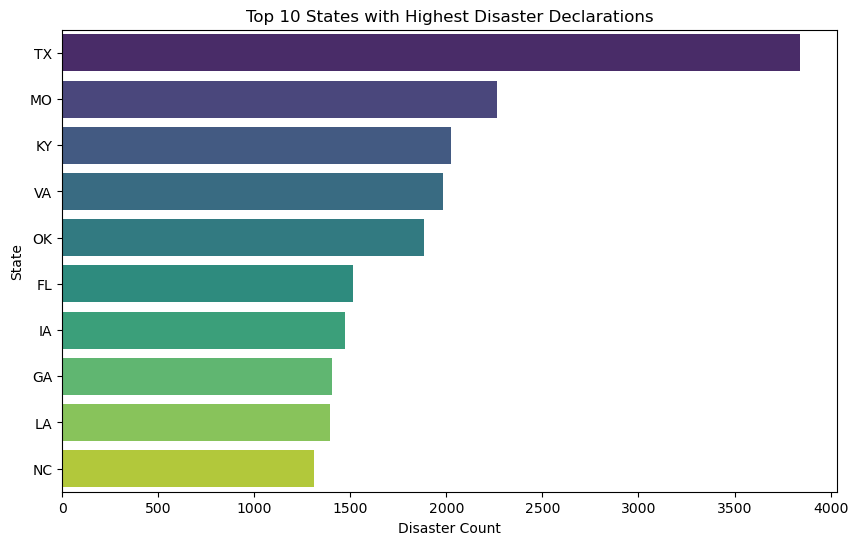

In [51]:
# Select top 10 states
top_states = state_counts.head(10)

# Create bar chart
plt.figure(figsize=(10,6))

sns.barplot(
    x='disaster_count',
    y='state',
    hue='state',         
    data=top_states,
    palette="viridis",
    legend=False          
)

plt.title("Top 10 States with Highest Disaster Declarations")
plt.xlabel("Disaster Count")
plt.ylabel("State")

plt.show()

## Disaster Type Analysis

The dataset is further analyzed by grouping disaster declarations based on both state and disaster type.

## Interpretation

Different states are affected by different types of disasters. This variation is influenced by geographical location and environmental conditions.

In [52]:
# Group data by state and incident type
state_incident = df.groupby(['state', 'incidentType']).size().reset_index(name='count')

# Display first few rows
print(state_incident.head())

  state incidentType  count
0    AK   Earthquake      7
1    AK         Fire     16
2    AK        Flood     46
3    AK        Other      4
4    AK         Snow      4


## Visualization: Disaster Type Distribution

A stacked bar chart is used to show how different disaster types contribute to total disasters in each state.

## Interpretation

The distribution highlights that certain disaster types are dominant in specific states. For example, coastal states are more prone to hurricanes, while western states experience more wildfires.

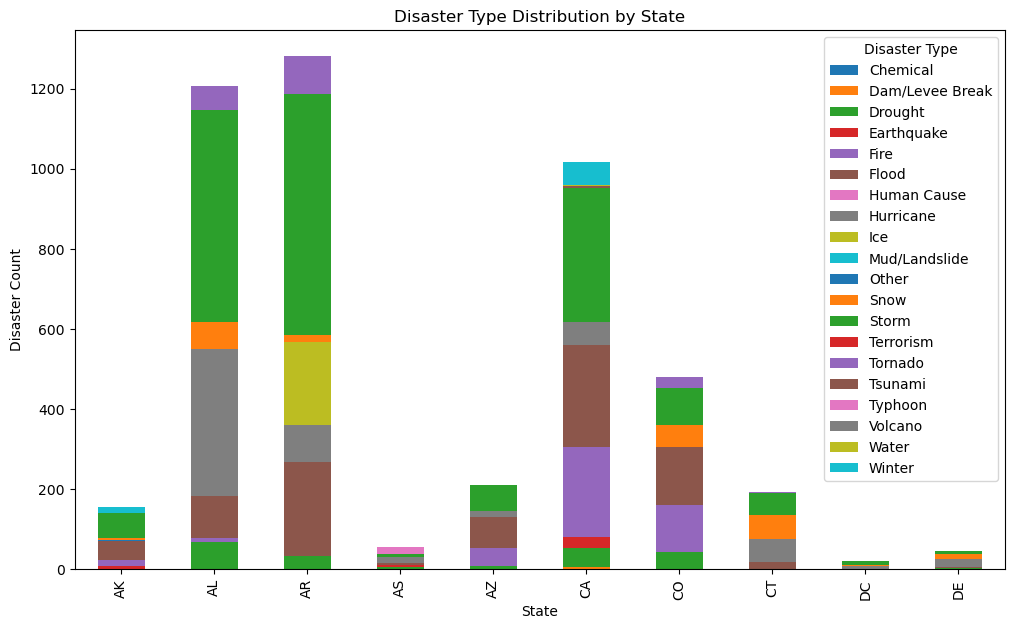

In [53]:
# Convert grouped data into pivot table
pivot_data = state_incident.pivot(
    index='state',
    columns='incidentType',
    values='count'
).fillna(0)

# Plot stacked bar chart (top 10 states for clarity)
pivot_data.head(10).plot(
    kind='bar',
    stacked=True,
    figsize=(12,7)
)

plt.title("Disaster Type Distribution by State")
plt.xlabel("State")
plt.ylabel("Disaster Count")

plt.legend(title="Disaster Type")

plt.show()

## Visualization: Hurricane Hotspots

A choropleth map is used to highlight hurricane-prone states.

## Interpretation

Hurricane occurrences are concentrated in coastal regions, especially along the Gulf and Atlantic coasts. These regions are more exposed to tropical storms and hurricanes.

In [54]:
# Filter hurricane disasters
hurricane = df[df['incidentType'] == "Hurricane"]

# Count hurricanes per state
hurricane_counts = hurricane.groupby('state').size().reset_index(name='count')

# Create map
import plotly.express as px

fig = px.choropleth(
    hurricane_counts,
    locations='state',
    locationmode="USA-states",
    color='count',
    scope="usa",
    color_continuous_scale="Blues",
    title="Hurricane Disaster Hotspots in the US"
)

fig.show()

## Monthly Trend Analysis

Disaster occurrences are analyzed across different months to identify seasonal patterns.

## Interpretation

The analysis shows variations in disaster frequency across months, indicating seasonal trends. Certain months experience higher disaster occurrences due to climatic conditions.

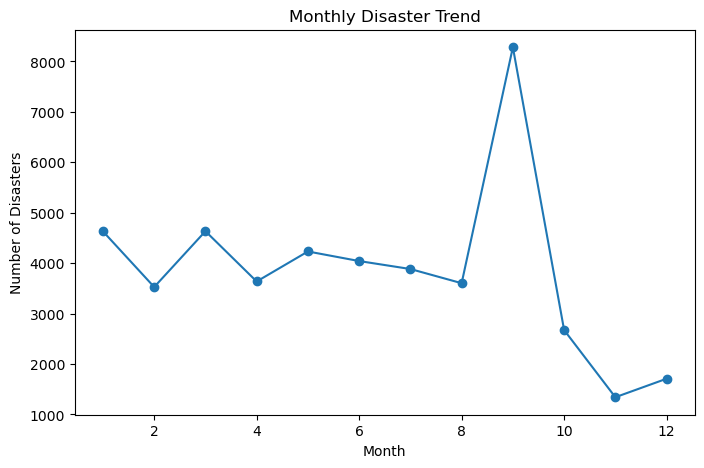

In [55]:
# Convert declarationDate to datetime
df['declarationDate'] = pd.to_datetime(df['declarationDate'], errors='coerce')

# Extract month
df['month'] = df['declarationDate'].dt.month

# Count disasters per month
monthly_counts = df.groupby('month').size()

plt.figure(figsize=(8,5))

monthly_counts.plot(kind='line', marker='o')

plt.title("Monthly Disaster Trend")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")

plt.show()

## Visualization: Overall Disaster Map

A choropleth map is created to display disaster declarations across all states.

## Interpretation

The map clearly shows geographical clustering of disasters. Southern states have higher disaster frequencies compared to other regions.

In [56]:
# Count disasters per state
state_counts = df.groupby('state').size().reset_index(name='disaster_count')

# Create choropleth map
import plotly.express as px

fig = px.choropleth(
    state_counts,
    locations='state',              # Correct column
    locationmode="USA-states",
    color='disaster_count',
    scope="usa",
    color_continuous_scale="Reds",
    title="Disaster Declarations Across U.S. States"
)

# Display map
fig.show()

## Regional Analysis

States are grouped into regions such as South, Midwest, West, and Northeast to analyze broader patterns.

## Interpretation

The South region has the highest disaster count, followed by the Midwest. The West and Northeast show relatively lower disaster occurrences.

      Region  disaster_count
0    Midwest           13890
1  Northeast            4319
2      South           22349
3       West            4232


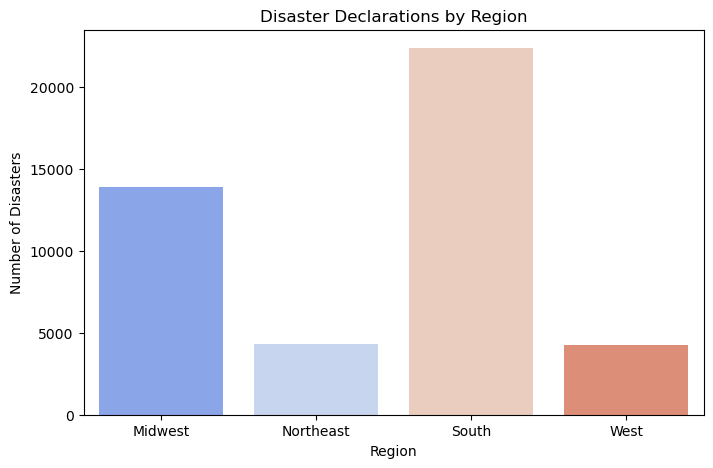

In [57]:
# Create region mapping for all states
region_map = {
    # West
    'WA':'West','OR':'West','CA':'West','NV':'West','ID':'West','MT':'West',
    'WY':'West','UT':'West','CO':'West','AZ':'West','NM':'West','AK':'West','HI':'West',

    # Midwest
    'ND':'Midwest','SD':'Midwest','NE':'Midwest','KS':'Midwest','MN':'Midwest',
    'IA':'Midwest','MO':'Midwest','WI':'Midwest','IL':'Midwest','IN':'Midwest',
    'MI':'Midwest','OH':'Midwest',

    # South
    'TX':'South','OK':'South','AR':'South','LA':'South','KY':'South','TN':'South',
    'MS':'South','AL':'South','WV':'South','VA':'South','NC':'South','SC':'South',
    'GA':'South','FL':'South','MD':'South','DE':'South',

    # Northeast
    'PA':'Northeast','NY':'Northeast','NJ':'Northeast','CT':'Northeast',
    'RI':'Northeast','MA':'Northeast','VT':'Northeast','NH':'Northeast','ME':'Northeast'
}

# Map regions to dataset (FIXED)
df['Region'] = df['state'].map(region_map)

# Count disasters per region
region_counts = df.groupby('Region').size().reset_index(name='disaster_count')

print(region_counts)


# -----------------------------------
# Visualization: Regional Comparison
# -----------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=region_counts,
    x='Region',
    y='disaster_count',
    hue='Region',
    palette='coolwarm',
    legend=False
)

plt.title("Disaster Declarations by Region")
plt.xlabel("Region")
plt.ylabel("Number of Disasters")

plt.show()

## Key Insights:

->Disaster occurrences are unevenly distributed across states

->Coastal regions experience more hurricanes and storms

->Western regions are prone to wildfires

->Seasonal trends influence disaster frequency

->Regional grouping helps identify broader spatial patterns

## Conclusion

The geographical analysis of natural disaster declarations reveals clear spatial patterns across the United States. Southern and coastal regions experience higher disaster frequencies due to exposure to hurricanes, floods, and storms, while western regions are more affected by wildfires. The use of visualizations such as bar charts and choropleth maps helps in identifying disaster-prone areas effectively. These insights are valuable for disaster management, preparedness, and policy planning.